In [59]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [60]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [61]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [62]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }

def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [63]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        if state == self.goal:
            return True
        else:
            return False


    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.

        legal_actions = []
        for action in MOVES:
            row,col = state
            r,c = MOVES[action]
            next_state= (row + r, col + c)
            if self.in_bounds(next_state) and self.is_free(next_state):
                legal_actions.append(action)

        return legal_actions


    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        row,col =state
        dr,dc = MOVES[action]
        next_state = (row + dr, col + dc)
        return next_state

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1


In [64]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [65]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [66]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

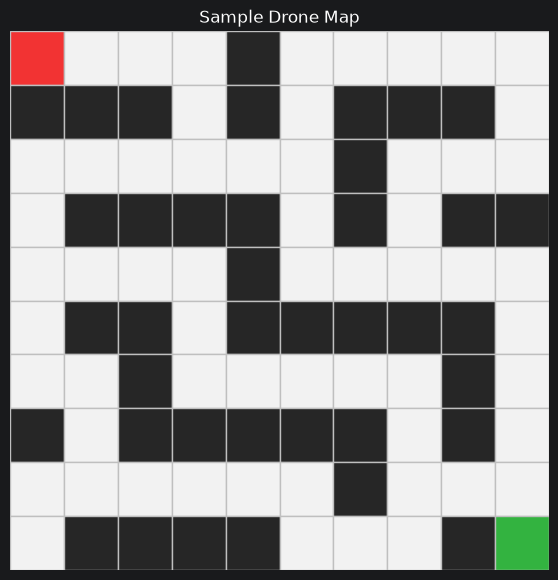

In [67]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [68]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)

        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s,action)
            cost = node.path_cost + problem.action_cost(s,action,s_prime)
            yield Node(state = s_prime, parent = node, action = action,path_cost = cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [69]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. If the initial state is the goal, return success.
        # 3. Create a deque frontier and add the initial node.
        # 4. Create a reached set and add the initial state.
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()

        nodes_expanded = 0
        max_frontier_size = 1

        node = Node(problem.initial_state())
        if problem.is_goal(node.state):
            return SearchResult( algorithm = "BFS", status = "success", solution = node,nodes_expanded = 0,max_frontier_size = 1,reached_count =1)

        frontier = deque([node])
        reached = {node.state}

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            s = node.state
            for action in problem.actions(s):
                s_prime = problem.result(s,action)
                cost = node.path_cost + problem.action_cost(s,action,s_prime)
                child = Node(state = s_prime, parent = node, action = action,path_cost = cost)

                if problem.is_goal(child.state):
                    return SearchResult( algorithm = "BFS", status = "success", solution = child,nodes_expanded = nodes_expanded,max_frontier_size = max_frontier_size,reached_count = len(reached))
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                    max_frontier_size = max(max_frontier_size,len(frontier))

        return SearchResult(algorithm = "BFS", status = "Failure", solution = None,nodes_expanded = nodes_expanded,max_frontier_size = max_frontier_size,reached_count =len (reached))


In [70]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        # 2. If the initial state is the goal, return success.
        # 3. Use a Python list as the stack frontier.
        # 4. Use a reached set.
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.

        node = Node(problem.initial_state())
        if problem.is_goal(node.state):
            return SearchResult( algorithm = "DFS", status = "success", solution = node,nodes_expanded = 0,max_frontier_size = 1,reached_count =1)
        nodes_expanded = 0
        max_frontier_size = 1

        frontier = [node]
        reached = {node.state}

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            children = list(self.expand(problem,node))
            children.reverse()

            for child in children :
                if problem.is_goal(child.state):
                    return SearchResult(algorithm = 'DFS',status = 'Success',solution = child,nodes_expanded = nodes_expanded,max_frontier_size = max_frontier_size,reached_count = len(reached))
                if child.state not in reached:
                    frontier.append(child)
                    reached.add(child.state)
            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(algorithm = 'DFS',status = 'Failure',solution = None,nodes_expanded = nodes_expanded,max_frontier_size = max_frontier_size,reached_count = len(reached))




In [71]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")

        if problem.is_goal(node.state):
            return node, "Success"
        elif node.depth >= limit:
            return None, "Cutoff"
        else:
            metrics["nodes_expanded"] += 1
            cutoff_occurred = False
            for child in self.expand(problem,node):
                ancestor = node
                on_path = False

                while ancestor is not None:
                    if ancestor.state == child.state:
                        on_path = True
                        break
                    ancestor  = ancestor.parent

                if on_path:
                    continue

                metrics["max_stack_size"] = max(metrics["max_stack_size"],current_stack_size + 1)

                result_node,result_status = self._recursive_dls(problem = problem,node = child,limit = limit,metrics = metrics,current_stack_size = current_stack_size + 1)
                if result_status == "Success":
                    return result_node, "Success"

                if result_status == "Cutoff":
                    cutoff_occurred = True

            if cutoff_occurred:
                return None, "Cutoff"
            else:
                return None, "Failure"

In [72]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)

        iteration_log = []
        total_nodes_expanded = 0
        max_frontier_size = 0

        dls = DepthLimitedSearch()
        for limit in range(max_depth + 1):
            result = dls.search(problem,limit = limit)

            total_nodes_expanded += result.nodes_expanded

            max_frontier_size = max(max_frontier_size,result.max_frontier_size)

            iteration_log.append({"limit":limit,"status":result.status,"nodes_expanded":result.nodes_expanded})

            if result.status == "Success":
                return SearchResult(algorithm = algorithm,status = "Success",solution = result.solution,nodes_expanded = total_nodes_expanded,max_frontier_size = max_frontier_size,reached_count = 0,limit = limit,iterations = iteration_log)

            if result.status == "Failure":
                return SearchResult(algorithm = algorithm,status = "Failure",solution = None,nodes_expanded = total_nodes_expanded,max_frontier_size = max_frontier_size,reached_count = 0,limit = limit,iterations = iteration_log)

        return SearchResult(algorithm = algorithm,status = "Cutoff",solution = None,nodes_expanded = total_nodes_expanded,max_frontier_size = max_frontier_size,reached_count = 0,limit = max_depth,iterations = iteration_log)




In [73]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,Success,NaN,26.0,26.0,37,4,39
2,DLS,Cutoff,10.0,NaN,NaN,16,11,0
3,IDS,Success,18.0,18.0,18.0,356,19,0


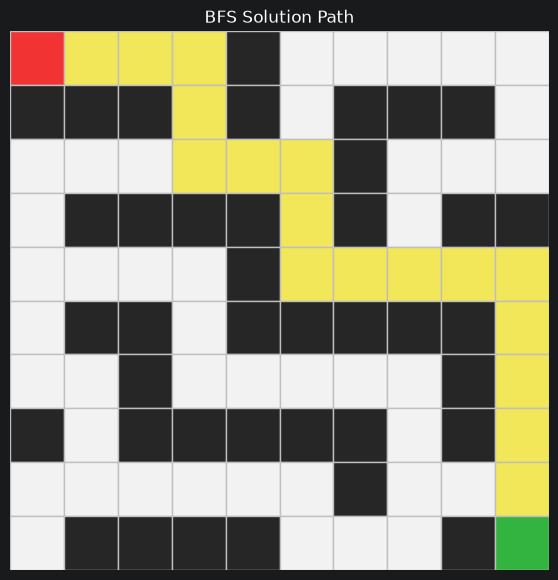

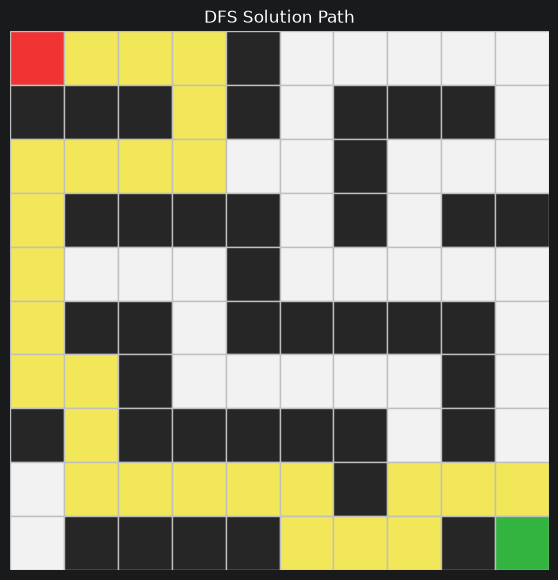

In [74]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)


In [75]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0,0,0,0,1,1,0,0,0,0],
    [0,1,1,1,0,0,0,0,1,0],
    [0,0,0,0,1,0,0,0,0,0],
    [0,1,0,1,0,0,1,0,0,0],
    [0,1,1,1,0,0,0,1,0,0],
    [0,0,0,1,0,1,0,1,1,0],
    [0,0,0,0,0,0,1,0,1,0],
    [0,0,0,0,0,1,0,0,0,0],
    [0,0,0,0,0,1,1,0,0,0],
    [0,0,0,0,1,1,0,0,0,0]
]

custom_start_1 = (0,0)
custom_goal_1 = (9,9)

# Example after completing:
# custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
# custom_results_1 = [
#     bfs.search(custom_problem_1),
#     dfs.search(custom_problem_1),
#     dls.search(custom_problem_1, limit=20),
#     ids.search(custom_problem_1, max_depth=40),
# ]
# show_results(custom_results_1)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
     bfs.search(custom_problem_1),
     dfs.search(custom_problem_1),
     dls.search(custom_problem_1, limit=20),
     ids.search(custom_problem_1, max_depth=40),
 ]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,26.0,26.0,65,5,66
1,DFS,Success,NaN,36.0,36.0,38,19,57
2,DLS,Cutoff,20.0,NaN,NaN,14892,21,0
3,IDS,Success,26.0,26.0,26.0,269461,27,0


In [76]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0,0,0,1,0,1,0,1,1,0,0,1],
    [0,1,0,0,0,0,1,0,1,0,0,0],
    [0,1,0,0,0,0,0,0,1,0,0,1],
    [1,1,1,0,0,0,0,0,0,0,1,1],
    [1,1,0,0,0,0,0,0,1,0,0,0],
    [0,0,1,0,0,0,0,0,0,0,0,1],
    [1,1,0,0,1,0,0,0,0,0,1,1],
    [0,0,0,0,0,0,0,1,1,0,1,0],
    [1,0,1,0,0,0,0,0,0,0,0,0],
    [0,1,0,1,1,0,1,0,0,0,0,0],
    [0,0,1,0,1,1,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0]
]

custom_start_2 = (0,2)
custom_goal_2 = (11,11)

# Example after completing:
# custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
# custom_results_2 = [
#     bfs.search(custom_problem_2),
#     dfs.search(custom_problem_2),
#     dls.search(custom_problem_2, limit=20),
#     ids.search(custom_problem_2, max_depth=40),
# ]
# show_results(custom_results_2)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
     bfs.search(custom_problem_2),
     dfs.search(custom_problem_2),
     dls.search(custom_problem_2, limit=20),
     ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,20,20,92,9,94
1,DFS,Success,NaN,32,32,66,29,91
2,DLS,Success,20.0,20,20,54789,21,0
3,IDS,Success,20.0,20,20,935821,21,0


15.1
1. A state in this lab refers to a single cell's coordinates in the grid. i.e.(row,col) pairs
2. An action in this lab is a single move from one cell to an adjacent cell. There are 4 actions in this lab;  UP,DOWN,LEFT, and RIGHT
3. Result returns the new (row,col) you land on after taking an action.
4. We do this because it makes the search algorithm reusable across completely different problems.

15.2
1 .A FIFO queue makes BFS expand nodes in the order they were discovered. i.e. oldest first, which means it fully explores depth 0, then depth 1, then depth 2, etc., guaranteeing a level-by-level search.
2. Because it expands level by level, BFS finds the goal at the shallowest possible depth — and since the grid is unweighted, depth = number of steps. The first time it reaches the goal, that path is guaranteed shortest.
3. The reached set tracks states already visited so BFS doesn't re-expand or re-queue them, avoiding infinite loops and redundant work.

15.3

1. A stack makes DFS expand the most recently discovered node first, so it dives deep along one path before backtracking.
2. No. DFS stops as soon as it finds any path to the goal, not the shortest one. It may find a long, winding path while a shorter one was available but unexplored.
3. DFS only needs to store one path from root to current node (plus siblings), so memory is roughly O(depth) — much less than BFS's O(branching factor^depth) frontier when the tree is deep but narrow.
4. DFS performs badly when the search space has very deep or infinite paths (especially without cycle/repeat detection), since it can get stuck exploring a long unproductive branch instead of finding a nearby goal.

15.4

1. If the depth limit is too small, DLS may never reach the goal even if a solution exists, because it cuts off search before reaching the depth where the goal actually is.
2. "cutoff" means the search hit the depth limit without finding the goal. It's different from "failure", which means the whole tree was exhausted with no solution at any depth.
3. DLS adds a maximum depth bound, so it stops expanding nodes deeper than that limit.
4. Path-cycle checking prevents revisiting a state already on the current path, avoiding infinite loops within the depth limit and wasted expansions on cycles.

15.5

1. IDS repeats DLS with increasing limits because it doesn't know the goal's depth in advance.
2. A single small-limit DLS gives up before reaching the goal if the goal is deeper than the limit. IDS keeps increasing the limit, so it eventually tries a limit ≥ the goal's depth, guaranteeing it will find the goal if one exists (assuming finite branching).
3. Like DFS, IDS only needs to store one path at a time (O(depth) memory), since each iteration is just a depth-limited DFS, it never holds a full frontier of nodes the way BFS does.
4. Lower levels get re-expanded on every iteration, but since the number of nodes grows exponentially with depth, the cost of redoing shallow levels is small compared to the final deepest level.

15.6

1. Factors like distance from obstacles, battery/fuel cost, wind exposure, altitude changes, no-fly zones, signal/GPS coverage, and avoiding densely populated areas could all make one route safer or more practical than another, even if it's not the shortest.
2. BFS. Since all moves cost the same, fewest moves = shortest path, and BFS is guaranteed to find the shallowest (fewest-step) solution first.
3. DLS. It lets you cap the search depth directly, useful if you need to bound how far the drone searches (e.g. limited battery/range) regardless of whether the goal is found.
4. The grid model ignores continuous space/movement, real obstacle shapes, battery/fuel limits, wind/weather, sensor uncertainty, dynamic obstacles (other drones, moving objects), and varying move costs. Real navigation is continuous, uncertain, and cost-varying, not a clean uniform grid.

15.1
1. A state in this lab refers to a single cell's coordinates in the grid. i.e.(row,col) pairs
2. An action in this lab is a single move from one cell to an adjacent cell. There are 4 actions in this lab;  UP,DOWN,LEFT, and RIGHT
3. Result returns the new (row,col) you land on after taking an action.
4. We do this because it makes the search algorithm reusable across completely different problems.

15.2
1 .A FIFO queue makes BFS expand nodes in the order they were discovered. i.e. oldest first, which means it fully explores depth 0, then depth 1, then depth 2, etc., guaranteeing a level-by-level search.
2. Because it expands level by level, BFS finds the goal at the shallowest possible depth — and since the grid is unweighted, depth = number of steps. The first time it reaches the goal, that path is guaranteed shortest.
3. The reached set tracks states already visited so BFS doesn't re-expand or re-queue them, avoiding infinite loops and redundant work.

15.3

1. A stack makes DFS expand the most recently discovered node first, so it dives deep along one path before backtracking.
2. No. DFS stops as soon as it finds any path to the goal, not the shortest one. It may find a long, winding path while a shorter one was available but unexplored.
3. DFS only needs to store one path from root to current node (plus siblings), so memory is roughly O(depth) — much less than BFS's O(branching factor^depth) frontier when the tree is deep but narrow.
4. DFS performs badly when the search space has very deep or infinite paths (especially without cycle/repeat detection), since it can get stuck exploring a long unproductive branch instead of finding a nearby goal.

15.4

1. If the depth limit is too small, DLS may never reach the goal even if a solution exists, because it cuts off search before reaching the depth where the goal actually is.
2. "cutoff" means the search hit the depth limit without finding the goal. It's different from "failure", which means the whole tree was exhausted with no solution at any depth.
3. DLS adds a maximum depth bound, so it stops expanding nodes deeper than that limit.
4. Path-cycle checking prevents revisiting a state already on the current path, avoiding infinite loops within the depth limit and wasted expansions on cycles.

15.5

1. IDS repeats DLS with increasing limits because it doesn't know the goal's depth in advance.
2. A single small-limit DLS gives up before reaching the goal if the goal is deeper than the limit. IDS keeps increasing the limit, so it eventually tries a limit ≥ the goal's depth, guaranteeing it will find the goal if one exists (assuming finite branching).
3. Like DFS, IDS only needs to store one path at a time (O(depth) memory), since each iteration is just a depth-limited DFS, it never holds a full frontier of nodes the way BFS does.
4. Lower levels get re-expanded on every iteration, but since the number of nodes grows exponentially with depth, the cost of redoing shallow levels is small compared to the final deepest level.

15.6

1. Factors like distance from obstacles, battery/fuel cost, wind exposure, altitude changes, no-fly zones, signal/GPS coverage, and avoiding densely populated areas could all make one route safer or more practical than another, even if it's not the shortest.
2. BFS. Since all moves cost the same, fewest moves = shortest path, and BFS is guaranteed to find the shallowest (fewest-step) solution first.
3. DLS. It lets you cap the search depth directly, useful if you need to bound how far the drone searches (e.g. limited battery/range) regardless of whether the goal is found.
4. The grid model ignores continuous space/movement, real obstacle shapes, battery/fuel limits, wind/weather, sensor uncertainty, dynamic obstacles (other drones, moving objects), and varying move costs. Real navigation is continuous, uncertain, and cost-varying, not a clean uniform grid.15.1
1. A state in this lab refers to a single cell's coordinates in the grid. i.e.(row,col) pairs
2. An action in this lab is a single move from one cell to an adjacent cell. There are 4 actions in this lab;  UP,DOWN,LEFT, and RIGHT
3. Result returns the new (row,col) you land on after taking an action.
4. We do this because it makes the search algorithm reusable across completely different problems.

15.1
1. A state in this lab refers to a single cell's coordinates in the grid. i.e.(row,col) pairs
2. An action in this lab is a single move from one cell to an adjacent cell. There are 4 actions in this lab;  UP,DOWN,LEFT, and RIGHT
3. Result returns the new (row,col) you land on after taking an action.
4. We do this because it makes the search algorithm reusable across completely different problems.

15.2
1 .A FIFO queue makes BFS expand nodes in the order they were discovered. i.e. oldest first, which means it fully explores depth 0, then depth 1, then depth 2, etc., guaranteeing a level-by-level search.
2. Because it expands level by level, BFS finds the goal at the shallowest possible depth — and since the grid is unweighted, depth = number of steps. The first time it reaches the goal, that path is guaranteed shortest.
3. The reached set tracks states already visited so BFS doesn't re-expand or re-queue them, avoiding infinite loops and redundant work.

15.3

1. A stack makes DFS expand the most recently discovered node first, so it dives deep along one path before backtracking.
2. No. DFS stops as soon as it finds any path to the goal, not the shortest one. It may find a long, winding path while a shorter one was available but unexplored.
3. DFS only needs to store one path from root to current node (plus siblings), so memory is roughly O(depth) — much less than BFS's O(branching factor^depth) frontier when the tree is deep but narrow.
4. DFS performs badly when the search space has very deep or infinite paths (especially without cycle/repeat detection), since it can get stuck exploring a long unproductive branch instead of finding a nearby goal.

15.4

1. If the depth limit is too small, DLS may never reach the goal even if a solution exists, because it cuts off search before reaching the depth where the goal actually is.
2. "cutoff" means the search hit the depth limit without finding the goal. It's different from "failure", which means the whole tree was exhausted with no solution at any depth.
3. DLS adds a maximum depth bound, so it stops expanding nodes deeper than that limit.
4. Path-cycle checking prevents revisiting a state already on the current path, avoiding infinite loops within the depth limit and wasted expansions on cycles.

15.5

1. IDS repeats DLS with increasing limits because it doesn't know the goal's depth in advance.
2. A single small-limit DLS gives up before reaching the goal if the goal is deeper than the limit. IDS keeps increasing the limit, so it eventually tries a limit ≥ the goal's depth, guaranteeing it will find the goal if one exists (assuming finite branching).
3. Like DFS, IDS only needs to store one path at a time (O(depth) memory), since each iteration is just a depth-limited DFS, it never holds a full frontier of nodes the way BFS does.
4. Lower levels get re-expanded on every iteration, but since the number of nodes grows exponentially with depth, the cost of redoing shallow levels is small compared to the final deepest level.

15.6

1. Factors like distance from obstacles, battery/fuel cost, wind exposure, altitude changes, no-fly zones, signal/GPS coverage, and avoiding densely populated areas could all make one route safer or more practical than another, even if it's not the shortest.
2. BFS. Since all moves cost the same, fewest moves = shortest path, and BFS is guaranteed to find the shallowest (fewest-step) solution first.
3. DLS. It lets you cap the search depth directly, useful if you need to bound how far the drone searches (e.g. limited battery/range) regardless of whether the goal is found.
4. The grid model ignores continuous space/movement, real obstacle shapes, battery/fuel limits, wind/weather, sensor uncertainty, dynamic obstacles (other drones, moving objects), and varying move costs. Real navigation is continuous, uncertain, and cost-varying, not a clean uniform grid.